# ResNet-56 for CIFAR-10 from Scratch in PyTorch 🚀

In this notebook, I implement the groundbreaking **ResNet-56** architecture from scratch using PyTorch and train it on the **CIFAR-10** dataset.This implementation is based directly on the specifications outlined in the original paper, "[Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385v1)" by He et al..

Here i will implement the Basic Block architecture given in the paper for training on the CIFAR10 dataset.

## Table of Contents 
1.  **The Degradation Problem**: Why do very deep "plain" networks fail?
2.  **The Solution: Residual Learning**: Introducing the magic of shortcut connections.
3.  **Implementation from Scratch**:
    * Setup & Data Loading
    * Building the `BasicBlock`
    * Assembling the Full ResNet-56 Architecture
4.  **Training the Model**: Setting hyperparameters and running the training loop.
5.  **Results & Analysis**: Visualizing our model's performance.

## 1. The Degradation Problem 

Traditionally, it was believed that deeper networks should always perform better than their shallower counterparts.However, researchers discovered a "degradation" problem: as networks got deeper, their accuracy would saturate and then rapidly degrade.

Surprisingly, this wasn't due to overfitting. A deeper model would perform worse on **both the training and test sets** than a shallower one. The ResNet paper demonstrates this with 20-layer and 56-layer "plain" networks on CIFAR-10, where the deeper network shows a higher training error.

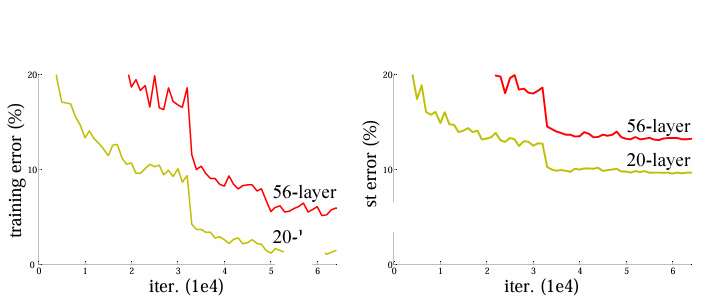

In [ ]:
#Import necessary libraries
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import MultiStepLR
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
torch.manual_seed(42) #for code reproducibility

In [ ]:
#Use gpu
device='cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device:{device}")

## 2. The Solution: Residual Learning 

The authors of ResNet hypothesized that the degradation problem was caused by the difficulty of optimizing very deep, plain networks. A deeper model should be able to perform *at least* as well as a shallower one by simply learning identity mappings for the extra layers. However, stacking non-linear layers makes it very hard to learn an identity function.

The solution is the **residual block**, which uses a "shortcut" or "skip connection" to bypass a few layers.

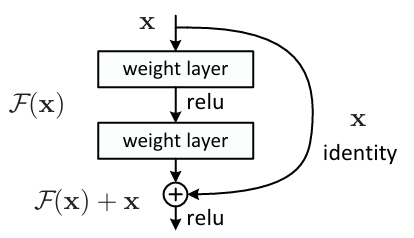

*Figure 2 from the paper: A residual learning block.*


Instead of forcing layers to learn the desired underlying mapping $H(x)$, we let them learn a **residual mapping**, $\mathcal{F}(x) = H(x) - x$. The original mapping is then recast as $\mathcal{F}(x) + x$.

$$y = \mathcal{F}(x, \{W_i\}) + x$$

If an identity mapping is optimal, the optimizer can easily push the weights of the convolutional layers in $\mathcal{F}(x)$ towards zero, making the block approximate $y=x$. This elegant solution makes optimization much easier and allows us to build substantially deeper—and more powerful—networks.

## 3. Implementation from Scratch

### Data Loading & Augmentation
We'll use the CIFAR-10 dataset.For our training data, we apply the exact augmentation strategy mentioned in the paper for the CIFAR-10 experiments:
* Pad each side of the 32x32 image with 4 pixels.
* Take a random 32x32 crop from the padded image.
* Apply a random horizontal flip.

We then normalize the images using the standard mean and standard deviation for the CIFAR-10 dataset.

In [ ]:
# Perform tranformations
train_transform=transforms.Compose([
    transforms.Pad(4), 
    transforms.RandomCrop(32), 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),   # CIFAR-10 mean 
        (0.2470, 0.2435, 0.2616))  # CIFAR-10 std
])

test_transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),   # CIFAR-10 mean 
        (0.2470, 0.2435, 0.2616))  # CIFAR-10 std
])

In [ ]:
# Load datasets
train_dataset=torchvision.datasets.CIFAR10(root='/kaggle/working/',train=True,download=True,transform=train_transform)
test_dataset=torchvision.datasets.CIFAR10(root='/kaggle/working/',train=False,download=True,transform=test_transform)

In [ ]:
# Create DataLoaders
train_loader=DataLoader(train_dataset,batch_size=128,num_workers=4,pin_memory=True)
test_loader=DataLoader(test_dataset,batch_size=128,num_workers=4,pin_memory=True)

###  Building the `BasicBlock`
This module defines the core building block of our ResNet. Each block consists of two `3x3` convolutional layers. The key feature is the shortcut connection.

For the CIFAR-10 architecture, the paper uses **Option A** for the shortcuts when dimensions change:
1.  When downsampling (stride=2), the shortcut path also subsamples the input feature map.
2.  When the number of channels increases, the shortcut path is padded with zeros to match the new dimension.

This ensures the entire shortcut path remains parameter-free.

In [ ]:
#Basic Block
class BasicBlock(nn.Module):
    def __init__(self,in_channel,out_channel,stride):
        super().__init__()
        self.in_channel=in_channel
        self.out_channel=out_channel
        self.stride=stride
        
        self.conv1=nn.Conv2d(in_channel,out_channel,kernel_size=3,padding=1,stride=stride,bias=False)
        self.bn1=nn.BatchNorm2d(out_channel)
        self.conv2=nn.Conv2d(out_channel,out_channel,kernel_size=3,padding=1,stride=1,bias=False)
        self.bn2=nn.BatchNorm2d(out_channel)
        self.relu=nn.ReLU(inplace=True)

    def forward(self,x):
        x1=self.relu(self.bn1(self.conv1(x)))
        x2=self.bn2(self.conv2(x1))

        # Shortcut connection to macth dimensions
        if self.stride!=1 or self.in_channel!=self.out_channel:
            shortcut=x[:,:,::self.stride,::self.stride]
            pad=(0,0,0,0,0,self.out_channel-self.in_channel)
            shortcut=F.pad(shortcut,pad,mode='constant',value=0)
        else:
            shortcut=x
        return self.relu(x2+shortcut)
        
    

### Assembling the ResNet-56 Architecture
Now we build the full network.The paper defines the CIFAR-10 architecture as follows:
- A single `3x3` convolutional layer.
- A stack of `6n` layers organized into 3 stages. Each stage has `2n` layers (`n` blocks).
- A final global average pooling layer and a fully-connected layer.

The total number of weighted layers is `6n + 2`. To build **ResNet-56**, we set **n=9**, which gives us `6*9 + 2 = 56` layers.

We also apply **Kaiming weight initialization**, as specified in the paper.

In [ ]:
class ResNet(nn.Module):
    def __init__(self,num_classes=10,n=9):
        super().__init__()
        self.n=n

        #First conv layer
        self.conv1=nn.Conv2d(3,16,kernel_size=3,stride=1,padding=1,bias=False)
        self.bn=nn.BatchNorm2d(16)
        self.relu=nn.ReLU(inplace=True)
        
        #3 Stages of Residual Blocks
        self.stage1=self._make_layers(16,16,num_blocks=self.n,stride=1)
        self.stage2=self._make_layers(16,32,num_blocks=self.n,stride=2)
        self.stage3=self._make_layers(32,64,num_blocks=self.n,stride=2)

        #Remaining layers for Classification
        self.pool=nn.AdaptiveAvgPool2d(1)
        self.fc=nn.Linear(64,num_classes)

        # Weight initialization 
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layers(self,in_channel,out_channel,num_blocks,stride):
        layers=[]
        #First block(for downsampling)
        layers.append(BasicBlock(in_channel,out_channel,stride))
        #Remaining
        for _ in range(1,num_blocks):
            layers.append(BasicBlock(out_channel,out_channel,stride=1))
        return nn.Sequential(*layers)

    def forward(self,x):
        out=self.relu(self.bn(self.conv1(x)))
        out=self.stage1(out)
        out=self.stage2(out)
        out=self.stage3(out)
        out=self.pool(out)
        out=torch.flatten(out,1)
        out=self.fc(out)
        return out
        

## 4. Training the Model
We instantiate our ResNet-56 model (`n=9`) and set up the training components, again following the paper:
- **Model**: `ResNet(n=9)` for 56 layers.
- **Loss Function**: `CrossEntropyLoss` for classification.
- **Optimizer**: `SGD` with a momentum of 0.9 and a weight decay of 0.0001.
- **Learning Rate Scheduler**: The initial learning rate is `0.1`. It's divided by 10 at 32k and 48k iterations. We calculate the corresponding epochs for our DataLoader.

In [ ]:
model=ResNet(num_classes=10,n=9).to(device) #Here we will use n=9 for 56 layer ResNet
#print(model) 

In [ ]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.1,momentum=0.9,weight_decay=1e-4)

# divide lr by 10 at epochs corresponding to 32k and 48k iterations
epoch_32k = int(32000 / len(train_loader))
epoch_48k = int(48000 / len(train_loader))
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[epoch_32k, epoch_48k], gamma=0.1)

In [ ]:
#Training loop

epochs=180 # Total training iterations in paper is 64k, which is ~164 epochs. We will train for 180.

train_losses=[]
train_accuracies=[]
val_accuracies=[]

for epoch in range(epochs):
    model.train()
    total_loss=0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            output=model(images)
            loss=criterion(output,labels)
            loss.backward()
            optimizer.step()
            #scheduler.step()

            total_loss+=loss.item()
            _,predicted=torch.max(output,1)
            total+=output.size(0)
            correct+=(predicted==labels).sum().item()
        
    avg_loss = total_loss / len(train_loader)
    train_acc=correct/total
    
    model.eval()
    correct_val=0
    total_val=0

    #evaluate
    with torch.no_grad():
        for images,labels in test_loader:
            images,labels=images.to(device),labels.to(device)
            output=model(images)
            _,predicted=torch.max(output,1)
            total_val+=labels.shape[0]
            correct_val+=(predicted==labels).sum().item()

        val_acc=correct_val/total_val

    # Store metrics for plotting
    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    scheduler.step() 

    
    #Print every 10th epoch
    if (epoch+1)%10==0:
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} Train Acc: {train_acc:.4f} Val Acc: {val_acc:.4f}")

#Note: Since we are training our model from scratch, it will take time

In [ ]:
# Define the path for saving the model
model_path = '/kaggle/working/resnet56_cifar10.pth'

# Save the model
torch.save(model.state_dict(), model_path)

## 5. Results & Analysis
Let's plot the validation accuracy and training loss over the epochs. As we can see, the model learns effectively, and the validation accuracy steadily increases, peaking around 92%. This demonstrates that our deep ResNet-56 model successfully overcame the degradation problem.

In [ ]:
#Plot graph for training accuracy vs val accuracy
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('ResNet-56 Training on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Visualize the results

classes = test_dataset.classes

# Pick 5 random samples from the test set
indices = random.sample(range(len(test_dataset)), 5)
images, labels = zip(*[test_dataset[i] for i in indices])
images_tensor = torch.stack(images).to(device)
labels_tensor = torch.tensor(labels).to(device)

# Get predictions
model.eval()
with torch.no_grad():
    outputs = model(images_tensor)
    _, preds = torch.max(outputs, 1)

# Unnormalize for display
def unnormalize(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    return img.cpu() * std + mean

# Plot
plt.figure(figsize=(12, 4))
for i in range(5):
    img = unnormalize(images_tensor[i])
    npimg = np.transpose(img.numpy(), (1, 2, 0))
    plt.subplot(1, 5, i + 1)
    plt.imshow(np.clip(npimg, 0, 1))
    plt.title(f"Pred: {classes[preds[i]]}\nGT: {classes[labels[i]]}")
    plt.axis("off")
plt.suptitle("ResNet-56 Predictions vs Ground Truth (CIFAR-10)")
plt.show()